# Part 0 - Importing Libraries and Datasets

In [ ]:
!pip install pyts

In [ ]:
# Importing the libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input
from pyts.image import GramianAngularField
from sklearn.preprocessing import MinMaxScaler
import shap
import matplotlib.pyplot as plt

In [ ]:
# Import the dataframe
df = pd.read_csv('/content/vvix_unscaled.csv')

# Print the head of df
df[:5]

,Date,VVIX_Close,VVIX_Close_Lag_1,VVIX_Close_Lag_5,VVIX_Close_Lag_10,VVIX_Close_Lag_21,VVIX_Close_Pct_Change,VVIX_Close_Log_Return,VVIX_Close_Rolling_Mean_5,VVIX_Close_Rolling_Mean_21,VIX_Close,SPX_Close
0,2007-02-02,72.440002,73.500000,81.360001,82.489998,87.629997,-0.014422,-0.014527,76.760001,83.500001,10.08,1448.390015
1,2007-02-05,70.290001,72.440002,81.680000,84.430000,88.190002,-0.029680,-0.030129,74.482001,82.647620,10.55,1446.989990
2,2007-02-06,68.550003,70.290001,78.900002,81.480003,90.169998,-0.024755,-0.025066,72.412001,81.618096,10.65,1448.000000
3,2007-02-07,70.320000,68.550003,77.279999,77.510002,92.040001,0.025821,0.025493,71.020001,80.583810,10.32,1450.020020
4,2007-02-08,73.180000,70.320000,73.500000,80.449997,92.760002,0.040671,0.039866,70.956001,79.651429,10.44,1448.310059


# Part 1 - Gramian Angular Field

In [ ]:
# Split the dataset into training and test sets
train_split_idx = int(len(df) * 0.8)
train_df = df.iloc[:train_split_idx].drop('Date', axis=1)
test_df = df.iloc[train_split_idx:].drop('Date', axis=1)

scaler = MinMaxScaler(feature_range=(-1, 1))
train_scaled = scaler.fit_transform(train_df)
test_scaled = scaler.transform(test_df) # Use transform, NOT fit_transform

# Recombine or process separately in window_maker
df_scaled = np.vstack((train_scaled, test_scaled))

# Window Maker
WINDOW_SIZE = 29
TARGET_OFFSET = 1 # Predict 1 day ahead

def window_maker(df, window_size, target_offset):
    X_raw = []
    y = []

    # Stop early enough to target - future_price - current_price
    for i in range(len(df) - window_size - target_offset):
      window = df[i : i + window_size]

      # Current price (last element in the window) should be a single scalar
      current_val = df[i + window_size - 1, 0]

      # Future price
      future_val = df[i + window_size + target_offset, 0]

      # Target is now a single scalar difference
      y.append(future_val - current_val)

      X_raw.append(window)

    return np.array(X_raw), np.array(y)

X_raw, y = window_maker(df_scaled, WINDOW_SIZE, TARGET_OFFSET)

# GADF Transformer
print("Applying GADF transform... (This folds time into space)")
gadf = GramianAngularField(image_size=WINDOW_SIZE, method='difference')

# Transform each channel independently, then stack them
X_gadf_channels = []
for i in range(X_raw.shape[2]): # For each feature
  # Flatten, transform and reshape
  channel = X_raw[:, :, i]
  image = gadf.fit_transform(channel)
  X_gadf_channels.append(image)

# Stack to get (Batch, 20, 20, 3)
X_gadf = np.stack(X_gadf_channels, axis=-1)

# Split into training and test data
train_size = int(len(X_gadf) * 0.8)
X_raw_train, X_raw_test = X_raw[:train_size], X_raw[train_size:]
X_gadf_train, X_gadf_test = X_gadf[:train_size], X_gadf[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Data Shapes Ready!")
print(f"Raw Sequence (LSTM Input): {X_raw_train.shape}")
print(f"GASF Sequence (ResNet Input): {X_gadf_train.shape}")

Applying GADF transform... (This folds time into space)
Data Shapes Ready!
Raw Sequence (LSTM Input): (3726, 29, 11)
GASF Sequence (ResNet Input): (3726, 29, 29, 11)


# Part 2 - ResNet-LSTM

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Model, Input, regularizers
from tensorflow.keras.layers import Input, Conv2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model

# --- 1. Custom Attention Layer ---
class Attention(layers.Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='att_weight', shape=(input_shape[-1], 1), initializer='normal')
        self.b = self.add_weight(name='att_bias', shape=(input_shape[1], 1), initializer='zeros')
        super(Attention, self).build(input_shape)

    def call(self, x):
        # x shape: (batch_size, time_steps, features)
        e = tf.tanh(tf.matmul(x, self.W) + self.b)
        a = tf.nn.softmax(e, axis=1) # Calculate weights for each time step
        output = x * a # Scale the input by the weights
        return tf.reduce_sum(output, axis=1) # Compress to (batch_size, features)

# --- 2. The Modified ResNet Block (Kept mostly the same) ---
def resnet_block(input_tensor, filters, kernel_size=3):
    x = layers.Conv2D(filters, kernel_size, padding='same')(input_tensor)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, kernel_size, padding='same')(x)
    x = layers.BatchNormalization()(x)

    if input_tensor.shape[-1] != x.shape[-1]:
        shortcut = layers.Conv2D(filters, kernel_size=1, padding='same')(input_tensor)
    else:
        shortcut = input_tensor

    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

# --- 3. The New Architecture ---
def build_vvix_specialist(window_size, n_features):
    # --- Branch 1: The "Eye" (Spatial/Pattern) ---
    input_img = Input(shape=(window_size, window_size, n_features), name="GADF_Input")

    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(input_img)
    x = resnet_block(x, 32)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.3)(x) # Added dropout to conv layers

    x = resnet_block(x, 64)
    x = layers.GlobalAveragePooling2D()(x) # flattens to vector
    visual_out = layers.Dense(32, activation='relu')(x)

    # --- Branch 2: The "Brain" (Temporal/Sequence) ---
    input_seq = Input(shape=(window_size, n_features), name="LSTM_Input")

    # Add kernel_regularizer to your Dense and LSTM layers
    y = layers.LSTM(64, return_sequences=True, kernel_regularizer=regularizers.l2(0.001))(input_seq)

    # LSTM with return_sequences=True so Attention can look at all steps
    y = layers.LSTM(64, return_sequences=True)(input_seq)
    y = layers.LSTM(64, return_sequences=True)(y)

    # Apply Attention: Focuses on specific days in the window
    y = Attention()(y)
    temporal_out = layers.Dense(32, activation='relu')(y)

    # --- Fusion ---
    combined = layers.concatenate([visual_out, temporal_out])

    # Deep Interpretability layers
    z = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001))(combined)
    z = layers.Dropout(0.5)(z) # Higher dropout for noisy financial data
    z = layers.Dense(32, activation='relu')(z)

    # Output: Predicting the DIFFERENCE (Change in VVIX)
    output = layers.Dense(1, activation='linear', name="Prediction")(z)

    model = Model(inputs=[input_img, input_seq], outputs=output)
    return model

# --- Usage (Copy this into your notebook) ---
model = build_vvix_specialist(WINDOW_SIZE, n_features=3)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='huber')
# Note: 'huber' loss is better for volatility than 'mse' because it handles spikes better!

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Define Callbacks (Safety Nets)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=10,
    factor=0.5,
    min_lr=1e-4
)

# Re-initialize the model with the correct number of features (11, from X_raw.shape[2])
# This ensures the model's input layers match the data shape.
model = build_vvix_specialist(WINDOW_SIZE, n_features=X_raw.shape[2])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='huber')

# 2. Train the Model
print("Starting Training...")
history = model.fit(
    x=[X_gadf_train, X_raw_train],
    y=y_train,
    epochs=50,
    batch_size=32,
    validation_data=([X_gadf_test, X_raw_test], y_test),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("Training complete!")
print(model.summary())

Starting Training...
Epoch 1/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - loss: 0.0398 - val_loss: 0.0205 - learning_rate: 0.0010
Epoch 2/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0124 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 3/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0066 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 4/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0052 - val_loss: 0.0062 - learning_rate: 0.0010
Epoch 5/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0048 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 6/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0046 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 7/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0045 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 8/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0045 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 9/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0044 - val_loss: 0.0057 - l

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ GADF_Input          │ (None, 29, 29,    │          0 │ -                 │
│ (InputLayer)        │ 11)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 29, 29,    │      3,200 │ GADF_Input[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 29, 29,    │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 29, 29,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 29, 29,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 29, 29,    │      9,248 │ activation_4[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 29, 29,    │        128 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 29, 29,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 29, 29,    │          0 │ add_2[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 14, 14,    │          0 │ max_pooling2d_1[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │     18,496 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 14, 14,    │     36,928 │ activation_6[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 14, 14,    │      2,112 │ dropout_2[0][0] 

 Total params: 428,252 (1.63 MB)

 Trainable params: 142,622 (557.12 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 285,246 (1.09 MB)

None


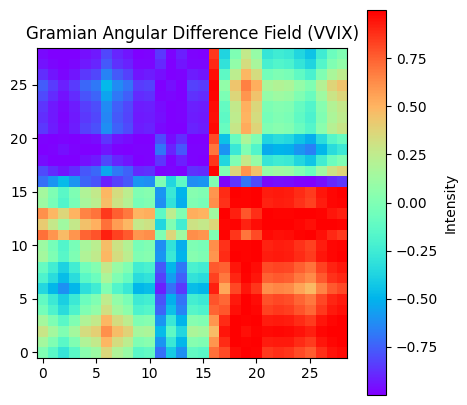

In [ ]:
import matplotlib.pyplot as plt
from pyts.image import GramianAngularField

# 1. Initialize the GAF transformer
# image_size matches your WINDOW_SIZE (29)
gasf = GramianAngularField(image_size=WINDOW_SIZE, method='difference')

# 2. Transform a single sample (the first one from the training set)
# X_raw_train shape is (samples, window_size, features)
sample_series = X_raw_train[0, :, 0].reshape(1, -1) # Taking VVIX channel
ga_image = gasf.fit_transform(sample_series)

# 3. Visualize the result
plt.figure(figsize=(5, 5))
plt.imshow(ga_image[0], cmap='rainbow', origin='lower')
plt.title('Gramian Angular Difference Field (VVIX)')
plt.colorbar(label='Intensity')
plt.show()

# Part 3 - Model Evaluation

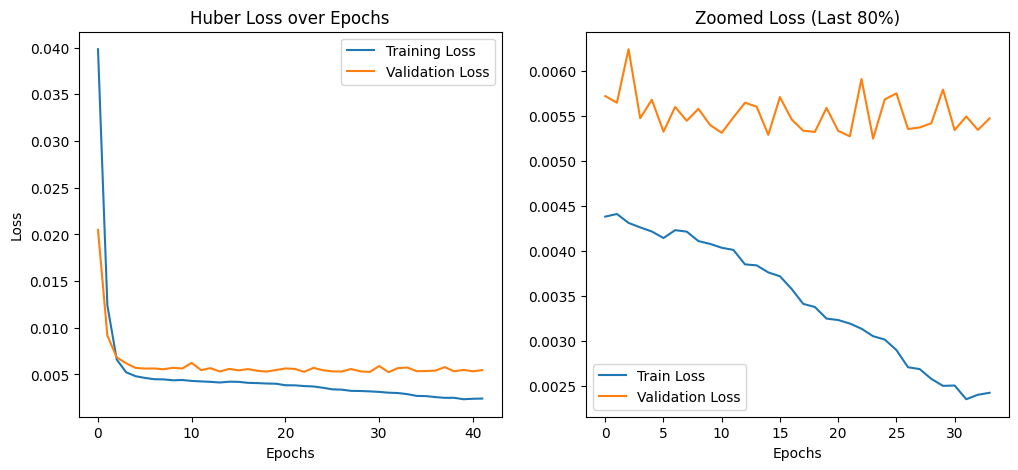

In [ ]:
# Visualizing Training Performance
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Huber Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Zoom in on the last 80% of epochs (to see fine details)
if len(history.history['loss']) > 10:
    plt.subplot(1, 2, 2)
    zoom_start = int(len(history.history['loss']) * 0.2)
    plt.plot(history.history['loss'][zoom_start:], label='Train Loss')
    plt.plot(history.history['val_loss'][zoom_start:], label='Validation Loss')
    plt.title('Zoomed Loss (Last 80%)')
    plt.xlabel('Epochs')
    plt.legend()

plt.show()

In [ ]:
# Generate Predictions & Evaluate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Make Predictions
# Model outputs scaled difference
pred_scaled_diff = model.predict([X_gadf_test, X_raw_test])

# 2. Inverse Transform Logic
# We need to reconstruct the actual price to make sense of the data.
# We know: Current_Price + Predicted_Diff = Predicted_Next_Price

# Get scaling factors for VVIX (column 0)
vvix_min = scaler.data_min_[0]
vvix_max = scaler.data_max_[0]
scale_factor = (vvix_max - vvix_min) / 2.0

# Unscale the predicted difference
pred_diff_real = pred_scaled_diff.flatten() * scale_factor
actual_diff_real = y_test.flatten() * scale_factor

# 3. Calculate Metrics
mse = mean_squared_error(actual_diff_real, pred_diff_real)
mae = mean_absolute_error(actual_diff_real, pred_diff_real)
r2 = r2_score(actual_diff_real, pred_diff_real)

print(f"\n--- Evaluation on Test Set (Real Points) ---")
print(f"Mean Squared Error: {mse:4f} points")
print(f"Root Mean Squared Error: {np.sqrt(mse):.4f} points")
print(f"Mean Absolute Error: {mae:.4f} points (Average miss)")
print(f"R-Squared: {r2:.4f} (Predictive Power)")

# 4. Directional Accuracy (The most important metric for trading)
# Did we predict the sign correctly? (Up vs Down)
correct_direction = np.sign(pred_diff_real) == np.sign(actual_diff_real)
dir_acc = np.mean(correct_direction)
print(f"Directional Accuracy: {dir_acc:.2%}")

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step

--- Evaluation on Test Set (Real Points) ---
Mean Squared Error: 56.777956 points
Root Mean Squared Error: 7.5351 points
Mean Absolute Error: 5.1570 points (Average miss)
R-Squared: 0.0883 (Predictive Power)
Directional Accuracy: 59.66%


In [ ]:
# Forecast Tomorrow
# 1. Get the very last window from the dataset
last_window_raw = df_scaled[-WINDOW_SIZE:]

# 2. Prepare Inputs
# Sequence Input
seq_input = last_window_raw.reshape(1, WINDOW_SIZE, X_raw.shape[2])

# Image Input (GADF)
last_window_channels = []
for i in range(X_raw.shape[2]): # Corrected from 'range(3)' to use actual number of features
    channel_data = last_window_raw[:, i].reshape(1, -1)
    img = gasf.transform(channel_data)
    last_window_channels.append(img[0])

gadf_input = np.stack(last_window_channels, axis=-1).reshape(1, WINDOW_SIZE, WINDOW_SIZE, X_raw.shape[2]) # Corrected from '3' to use actual number of features

# 3. Predict
scaled_prediction = model.predict([gadf_input, seq_input])[0][0]

# 4. Convert to Real Price
real_diff_prediction = scaled_prediction * scale_factor
last_actual_price = df.iloc[-1, 1] # Changed from df.iloc[-1, 0] to df.iloc[-1, 1] to get VVIX_Close
forecast_price = last_actual_price + real_diff_prediction

print(f"\n========================================")
print(f"Current VVIX Price:      {last_actual_price:.2f}")
print(f"Predicted Move:          {real_diff_prediction:+.2f}")
print(f"FORECAST for Next Day:   {forecast_price:.2f}")
print(f"========================================")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step

Current VVIX Price:      94.10
Predicted Move:          +1.67
FORECAST for Next Day:   95.77


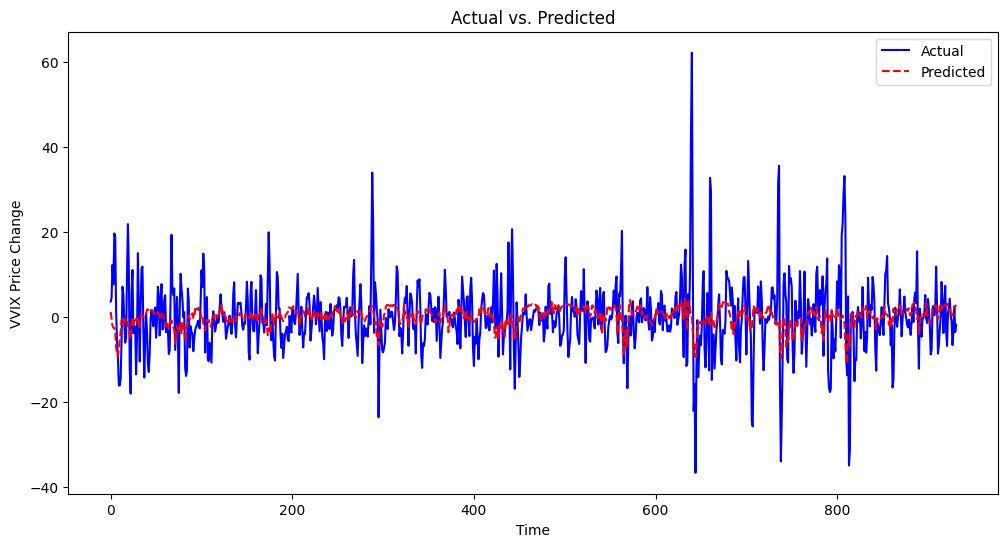

<Figure size 640x480 with 0 Axes>

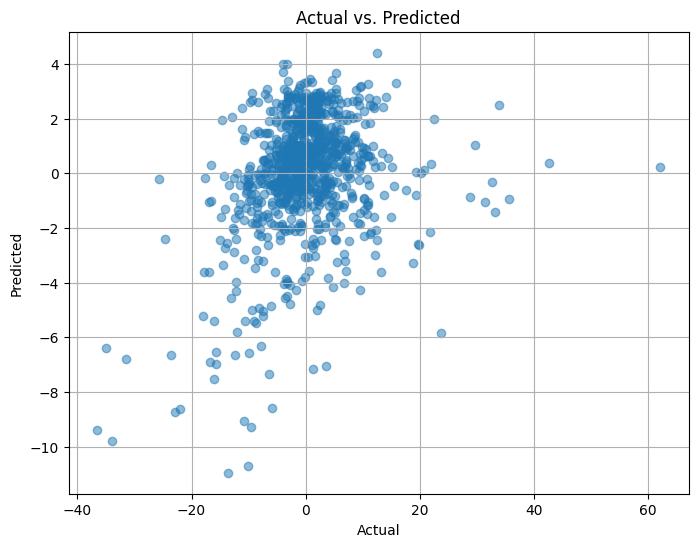

<Figure size 640x480 with 0 Axes>

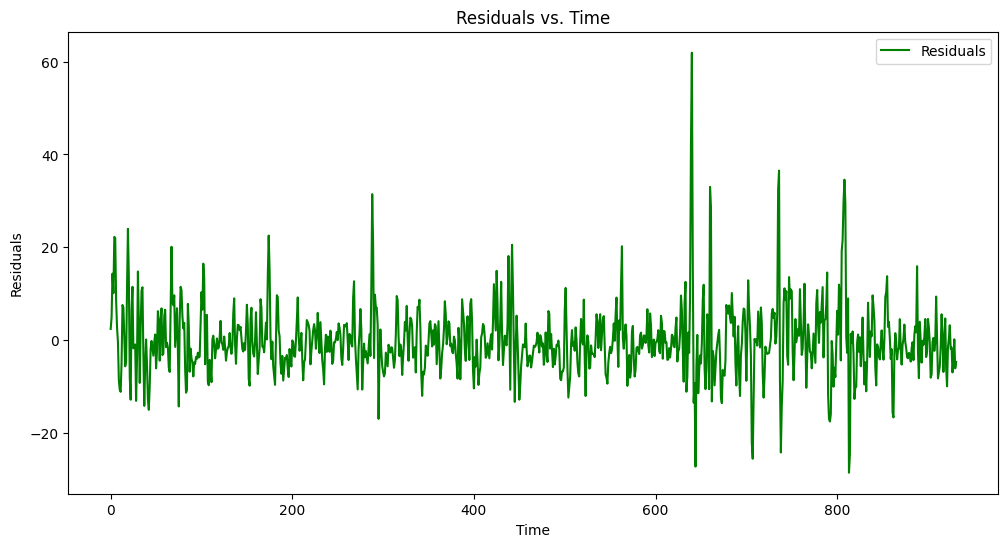

<Figure size 640x480 with 0 Axes>

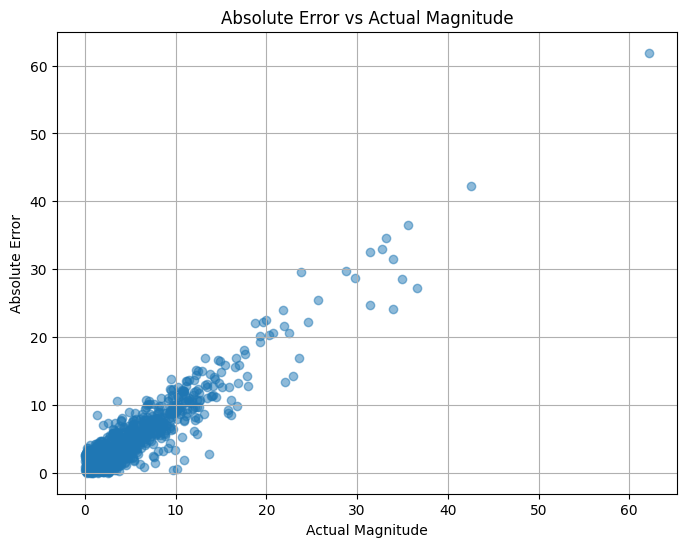

<Figure size 640x480 with 0 Axes>

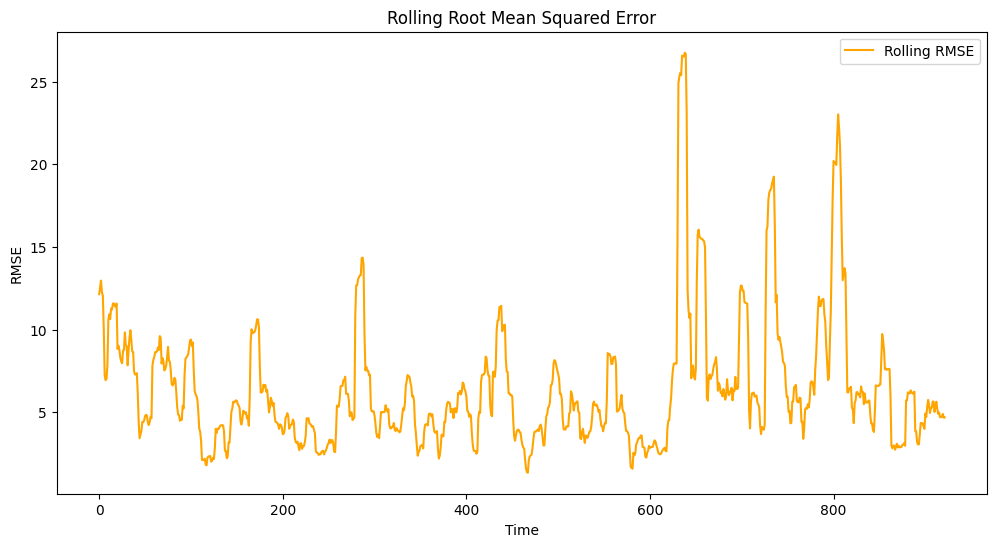

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plotting the graphs
## Actual vs. Predicted
plt.figure(figsize=(12, 6))
plt.plot(actual_diff_real, label='Actual', color='blue')
plt.plot(pred_diff_real, label='Predicted', color='red', linestyle='--')
plt.title('Actual vs. Predicted')
plt.xlabel('Time')
plt.ylabel('VVIX Price Change')
plt.legend()
plt.show()
plt.savefig('actual_vs_predicted.png')

## Scatter Plot (Actual vs. Predicted)
plt.figure(figsize=(8, 6))
plt.scatter(actual_diff_real, pred_diff_real, alpha=0.5)
plt.title('Actual vs. Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.show()
plt.savefig('actual_vs_predicted_scatter.png')

## Residual vs Time
residuals = actual_diff_real - pred_diff_real
plt.figure(figsize=(12, 6))
plt.plot(residuals, label='Residuals', color='green')
plt.title('Residuals vs. Time')
plt.xlabel('Time')
plt.ylabel('Residuals')
plt.legend()
plt.show()
plt.savefig('residuals_vs_time.png')

## Absolute Error vs Actual Magnitude
abs_errors = np.abs(residuals)
actual_magnitude = np.abs(actual_diff_real)
plt.figure(figsize=(8,6))
plt.scatter(actual_magnitude, abs_errors, alpha=0.5)
plt.xlabel("Actual Magnitude")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Actual Magnitude")
plt.grid(True)
plt.show()
plt.savefig("absolute_error_vs_actual_magnitude.png")

## Rolling RMSE
rolling_rmse = []
for i in range(len(actual_diff_real) - 10):
  y_t = actual_diff_real[i:i+10]
  y_p = pred_diff_real[i:i+10]
  rmse = np.sqrt(mean_squared_error(y_t, y_p))
  rolling_rmse.append(rmse)

plt.figure(figsize=(12,6))
plt.plot(rolling_rmse, label='Rolling RMSE', color='orange')
plt.title('Rolling Root Mean Squared Error')
plt.xlabel('Time')
plt.ylabel('RMSE')
plt.legend()
plt.show()
plt.savefig("rolling_rmse.png")

# Part 4 - SHAP

Calculating SHAP values... (this might take a minute)


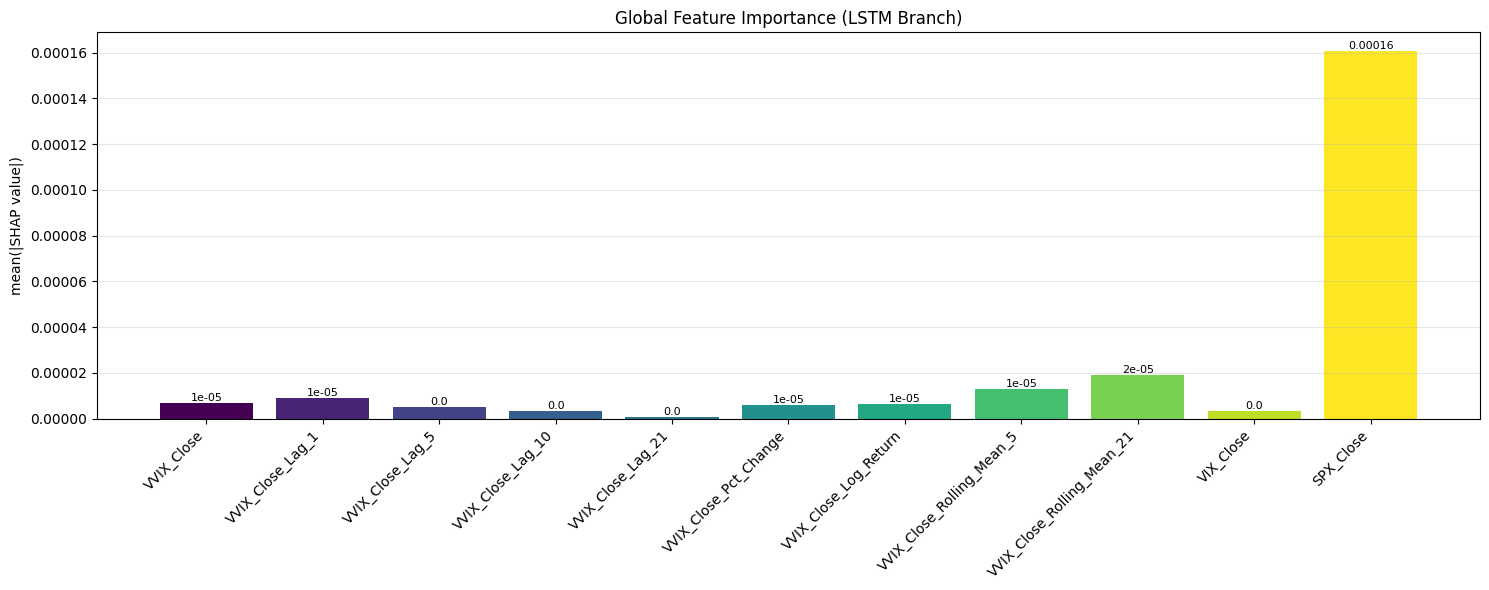

Calculating model base value...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
Model Base Value: -0.0089
Generating Force Plot for the first sample...


In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Select Background Data ---
bg_idx = np.random.choice(X_gadf_train.shape[0], 50, replace=False)
background_inputs = [X_gadf_train[bg_idx], X_raw_train[bg_idx]]

# --- 2. Initialize Explainer ---
explainer = shap.GradientExplainer(model, background_inputs)

# --- 3. Calculate SHAP Values ---
# Using a small subset for speed
test_idx = np.random.choice(X_gadf_test.shape[0], 20, replace=False)
test_inputs = [X_gadf_test[test_idx], X_raw_test[test_idx]]

print("Calculating SHAP values... (this might take a minute)")
shap_values = explainer.shap_values(test_inputs)

# --- 4. Process Dimensions (The Fix) ---
# shap_values[1] is the LSTM input. Shape might be (20, 29, 3, 1).
# We want to squeeze out that last '1' dimension.
seq_shap = np.array(shap_values[1])
if seq_shap.ndim == 4:
    seq_shap = np.squeeze(seq_shap, axis=-1) # Now shape is (20, 29, 3)

# --- 5. Visualize Feature Importance ---
# Dynamically get feature names from the original DataFrame columns, excluding 'Date'
feature_names = df.drop('Date', axis=1).columns.tolist()

# Mean absolute importance across all samples (axis 0) and time steps (axis 1)
feature_importance = np.mean(np.abs(seq_shap), axis=(0, 1))

# Plot
plt.figure(figsize=(15, 6)) # Increased figure size to accommodate more bars
bars = plt.bar(feature_names, feature_importance, color=plt.cm.viridis(np.linspace(0, 1, len(feature_names)))) # Use a colormap for more colors

plt.title('Global Feature Importance (LSTM Branch)')
plt.ylabel('mean(|SHAP value|)')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Add labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 5), va='bottom', ha='center', fontsize=8)

plt.show()

# --- 6. Single Prediction Force Plot ---
# --- Fix: Calculate Expected Value Manually ---
# Since explainer.expected_value is missing, we calculate the average prediction
# on the background dataset ourselves.
print("Calculating model base value...")
background_preds = model.predict(background_inputs)
expected_value = background_preds.mean()

print(f"Model Base Value: {expected_value:.4f}")
print("Generating Force Plot for the first sample...")

# --- Prepare Data for Plotting ---
# We focus on the LSTM (Sequence) branch for interpretability.
# Feature 0: VVIX, Feature 1: VIX, Feature 2: SPX
# Use the dynamically generated feature_names here too
sample_idx = 0

# 1. Get SHAP values for the sequence input (Input index 1)
# Check shapes to handle potential extra dimensions like (20, 29, 3, 1)
seq_shap_values = np.array(shap_values[1])
if seq_shap_values.ndim == 4:
    seq_shap_values = np.squeeze(seq_shap_values, axis=-1)

# 2. Aggregation: Sum impact over the 29 time steps
# Result shape: (11,) -> Total impact of all features over the window
shap_sample_agg = np.sum(seq_shap_values[sample_idx], axis=0)

# 3. Aggregation: Average feature value for display
# Result shape: (11,)
data_sample_agg = np.mean(test_inputs[1][sample_idx], axis=0)

# --- Plot ---
shap.initjs()
shap.plots.force(
    expected_value,
    shap_sample_agg,
    data_sample_agg,
    feature_names=feature_names
)
# plt.show() # plt.show() is not needed for the default JS plot, and can cause issues